# Cell-cycle phase visualization for burst kinetics txburst

This notebook loads GM12878 txburst results for **G1**, **S**, and **G2M**, computes four burst-kinetic quantities, and visualizes only:

- `bf`
- `bs`

Outputs are saved under `results/cellcycle_burst_visualization/`.


In [17]:
# ================================
# 0. Imports and plotting style
# ================================
from pathlib import Path
import warnings
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.colors as mcolors

import matplotlib.pyplot as plt
from matplotlib import rcParams, rcParamsDefault

rcParams.update(rcParamsDefault)
rcParams['pdf.fonttype'] = 42
sns.set(context = 'paper' , style='ticks' , 
    rc = {
        'figure.autolayout' : True,
        'font.sans-serif': ['Arial', 'Helvetica'],  # Specify Arial or Helvetica
        'axes.titlesize' : 6 ,
        'axes.titleweight' :'regular',
        
        'figure.titleweight' : 'regular' ,
        'figure.titlesize' : 6 ,
        'figure.labelsize' : 6 ,
        'figure.labelweight' : 'regular' , 
        
        'axes.labelsize' : 6 ,
        'axes.labelpad' : 2 ,
        'axes.labelweight' : 'regular' , 
        'axes.spines.top' : False,
        'axes.spines.right' : False,
        
        'legend.fontsize' : 6 ,
        'figure.figsize' : (8/2.54, 8/2.54) , 
        'figure.dpi': 300,      
        'figure.facecolor': 'w',
        'figure.edgecolor': 'black',   
        'legend.edgecolor': 'black',
        'legend.labelcolor': 'black',  # 设置图例标签字体颜色（在新版matplotlib中支持）
        'axes.edgecolor': 'black',
        'axes.labelcolor': 'black',
        'xtick.color': 'black',
        'ytick.color': 'black',
        'axes.titlecolor': 'black',
        'axes.labelcolor': 'black',

        'xtick.labelsize': 6,
        'ytick.labelsize': 6,
        'xtick.direction' : 'out' ,
        'ytick.direction' : 'out' ,
        'xtick.major.width': 0.5,  # X轴刻度主刻度线宽度
        'ytick.major.width': 0.5, 
        'xtick.major.size' : 2 ,
        'ytick.major.size' : 2 ,
        'xtick.minor.size': 2,  # X-axis minor tick length
        'ytick.minor.size': 2,  # Y-axis minor tick length

        'xtick.major.pad' : 2,
        'ytick.major.pad' : 2,
        'text.color': 'black',  # 全局文字颜色

        'lines.linewidth' : 0.75  , 
        'axes.linewidth': 0.5,  # Axis line width
        'savefig.dpi': 300,  # Save resolution 
        'savefig.bbox': 'tight',  # Tight bounding box       
        }
    )


# COLOR_MAP = {'H3K4me1':'#A28F19','H3K4me3':'#7FA5D0','H3K9me3':'#FDE4A4','H3K27ac':'#F5B6AC','H3K27me3':'#7CA68B','H3K36me3':'#80448A','H3K9ac':'#C7886D'}
COLOR_MAP = {'H3K4me1':'#BB72AC','H3K4me3':'#56B4E6','H3K9me3':'#7CC9C1','H3K27ac':'#EC6D5D','H3K27me3':'#F4DE28','H3K36me3':'#88C463','H3K9ac':'#3D60AC'}

COLORS = ['#39729C', "#D8B66F"]



## Origin

### label consistency

In [18]:
import pandas as pd
from functools import reduce
from pathlib import Path

BASE_DIR = Path("extra/datasets/processed/v2/meta_datasets")
PARSE_ORIGIN = 'origin'
BURST_METHOD = 'txburst'
FILES = {
    "all": BASE_DIR / "meta_data_E116_delay_1.0_with_cellsize_1.csv",
    "G1": BASE_DIR / "meta_data_E116_delay_1.0_with_cellsize_1_cellcycle_G1.csv",
    "S": BASE_DIR / "meta_data_E116_delay_1.0_with_cellsize_1_cellcycle_S.csv",
    "G2M": BASE_DIR / "meta_data_E116_delay_1.0_with_cellsize_1_cellcycle_G2M.csv",
}

KEEP_COLS = [
    "gene_id",
    "bs", "bf", "cv", "mean",
    "bs_label", "bf_label", "cv_label", "mean_label",
]


def load_and_rename(path, tag, keep_cols=KEEP_COLS):
    """
    Read one metadata file and add suffix to value columns.

    Example:
        bs -> bs_G1
        bf_label -> bf_label_G1
    """
    df = pd.read_csv(path)

    missing = [c for c in keep_cols if c not in df.columns]
    if missing:
        raise ValueError(f"{path} missing columns: {missing}")

    df = df[keep_cols].copy()

    # 防止 gene_id 重复导致 merge 后行数膨胀
    if df["gene_id"].duplicated().any():
        n_dup = int(df["gene_id"].duplicated().sum())
        print(f"[Warning] {tag}: duplicated gene_id rows = {n_dup}. Keeping first.")
        df = df.drop_duplicates(subset="gene_id", keep="first")

    rename_map = {
        c: f"{c}_{tag}"
        for c in df.columns
        if c != "gene_id"
    }

    df = df.rename(columns=rename_map)

    return df


dfs = [
    load_and_rename(path, tag)
    for tag, path in FILES.items()
]

meta_data_merge = reduce(
    lambda left, right: pd.merge(
        left,
        right,
        on="gene_id",
        how="inner",
        validate="one_to_one",
    ),
    dfs,
)

print(meta_data_merge.shape)
print(meta_data_merge.head())



(13703, 33)
           gene_id    bs_all    bf_all       cv_all  mean_all  bs_label_all  \
0  ENSG00000143320  0.001000  0.863205  1159.628102  0.000863             0   
1  ENSG00000143319  0.281646  2.443336     1.768196  0.688156             1   
2  ENSG00000143318  0.001000  2.071397   483.188478  0.002072             0   
3  ENSG00000143315  0.033329  3.150701     9.786973  0.105009             1   
4  ENSG00000143303  0.115711  1.598705     5.785442  0.184988             1   

   bf_label_all  cv_label_all  mean_label_all     bs_G1  ...  cv_label_S  \
0             0             1               0  0.001354  ...           0   
1             1             0               1  0.120038  ...           0   
2             1             1               0  0.001324  ...           1   
3             1             1               1  0.010955  ...           1   
4             1             1               1  0.057067  ...           1   

   mean_label_S    bs_G2M    bf_G2M      cv_G2M  mean_G2

/var/folders/tg/cls39crs76x43ks_vyxx1cgr0000gn/T/ipykernel_12087/2674660358.py:49: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(xticklabels, rotation=0)
/var/folders/tg/cls39crs76x43ks_vyxx1cgr0000gn/T/ipykernel_12087/2674660358.py:49: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(xticklabels, rotation=0)


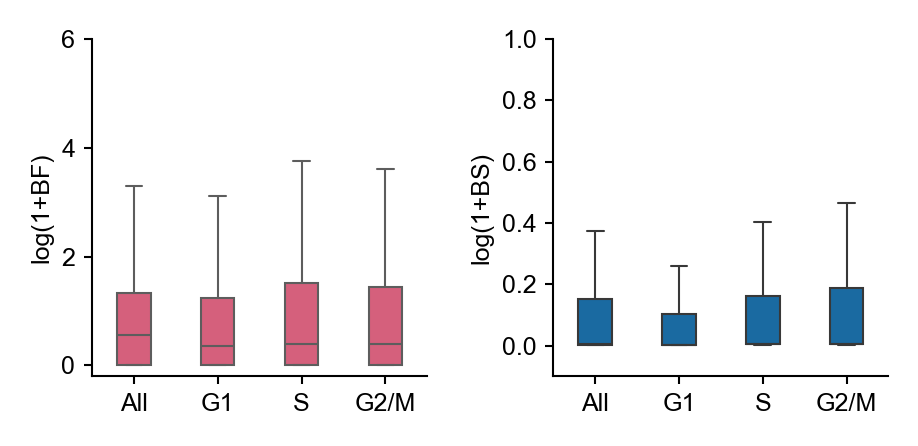

In [19]:
# import numpy as np
# import pandas as pd
# import matplotlib.pyplot as plt
# import seaborn as sns

PHASES = ["all", "G1", "S", "G2M"]
METRICS = ["bf", "bs"]
palette = ['#E94C72','#036EB8']
def make_long_df(df, metric, phases=PHASES):
    plot_df = pd.DataFrame({
        "phase": np.repeat(phases, len(df)),
        "value": np.concatenate([
            np.log1p(df[f"{metric}_{phase}"].values)
            for phase in phases
        ])
    })
    plot_df = plot_df.replace([np.inf, -np.inf], np.nan).dropna()
    return plot_df

fig, axes = plt.subplots(
    1, 2,
    figsize=(8 / 2.54, 4 / 2.54),
    sharey=False
)

for ax, metric in zip(axes, METRICS):
    plot_df = make_long_df(meta_data_merge, metric)
    color = palette[0] if metric == 'bf' else palette[1]
    sns.boxplot(
        data=plot_df,
        x="phase",
        y="value",
        order=PHASES,
        width=0.4,
        fliersize=0,
        linewidth=0.5,
        color=color,
        ax=ax,
    )

    if metric == 'bf':
        ax.set_ylim(-0.2, top=6)
    if metric == 'bs':
        ax.set_ylim(-0.1, top=1)

    ax.set_xlabel("")
    ax.set_ylabel(f"log(1+{metric.upper()})")
    xticklabels = ['All', 'G1', 'S', 'G2/M', ]
    ax.set_xticklabels(xticklabels, rotation=0)
    # ax.set_title(f"{metric}")

    # sns.despine(ax=ax)

# fig.suptitle("Burst kinetics stratified by cell-cycle phase\nusing original cell-cycle labels", y=0.95)
plt.tight_layout()
plt.savefig(f"benchmarks/revised_v2/reviewer4/figures/cellcycle_burst_metrics_boxplot_{PARSE_ORIGIN}_{BURST_METHOD}.eps", format='eps', bbox_inches='tight')
plt.show()

In [20]:
meta_data_merge[['bs_all', 'bs_G1', 'bs_S', 'bs_G2M']].describe()

,bs_all,bs_G1,bs_S,bs_G2M
count,13703.000000,13703.000000,13703.000000,13703.000000
mean,0.503006,0.205675,1.363847,1.330841
std,12.070037,2.381084,38.702893,28.724852
min,0.001000,0.001034,0.001000,0.001000
25%,0.001000,0.001377,0.003857,0.003865
50%,0.006305,0.001418,0.003934,0.003944
75%,0.162845,0.109941,0.177473,0.207273
max,1083.688407,203.951455,3032.353185,1345.470662


### compute bs bf label consistencies

In [21]:
import numpy as np
import matplotlib.colors as mcolors


phases = ["all","G1", "S", "G2M"]
consistency_matrix = np.zeros((len(phases), len(phases), 4))  # 2 for bf and bs
for idx, indicator in enumerate(["bf", "bs",]):
    for i, phase1 in enumerate(phases):
        for j, phase2 in enumerate(phases):
            consistency = meta_data_merge[meta_data_merge[f"{indicator}_label_{phase1}"] == meta_data_merge[f"{indicator}_label_{phase2}"]].shape[0] / meta_data_merge.shape[0]
            consistency_matrix[i, j, idx] = consistency




### plot heatmap

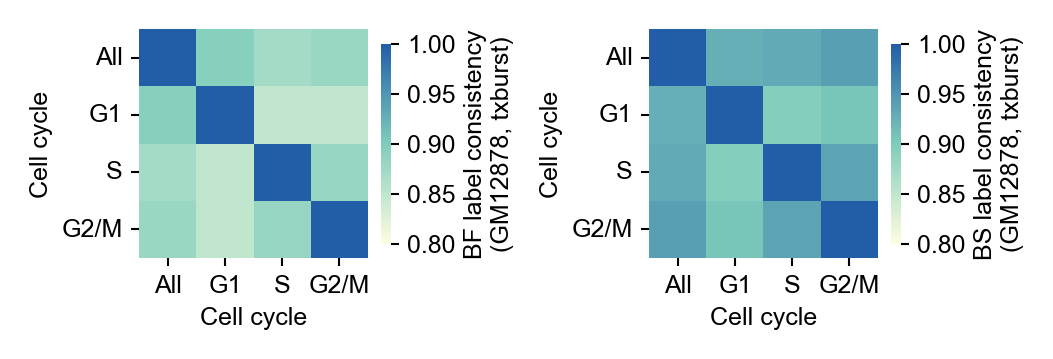

In [22]:
COLORS = ['#FFFDDF', "#7FCDBB", "#225EA8"]

fig, ax = plt.subplots(1,2, figsize=(9/2.54, 4/2.54))

for idx, indicator in enumerate(["bf", "bs",]):
    vmin = 0.8 if indicator == 'bf' else 0.8
    sns.heatmap(consistency_matrix[:,:,idx],cbar_kws={"shrink": 0.6, "fraction": 0.05},vmin=vmin, vmax=1,cmap=mcolors.LinearSegmentedColormap.from_list("colormap", COLORS, N=100), ax=ax[idx])

    ticklabels = ['All', 'G1', 'S', 'G2/M', ]
    ax[idx].set_xticklabels(ticklabels,rotation=0)
    ax[idx].set_yticklabels(ticklabels,rotation=0)
    ax[idx].set_aspect('equal')
    ax[idx].tick_params(axis='both',width=0.5)  # 修改刻度标签字体大小
    ax[idx].set_xlabel('Cell cycle', fontsize=6)
    ax[idx].set_ylabel('Cell cycle', fontsize=6)
    cbar = ax[idx].collections[0].colorbar
    # 调整colorbar的刻度粗细
    cbar.ax.tick_params(width=0.5,)  # 设置colorbar刻度的粗细
    cbar.set_label(f'{indicator.upper()} label consistency\n(GM12878, {BURST_METHOD})',fontsize=6)

# fig.suptitle("Consistency of burst label across cell cycles\nusing original cell-cycle labels", y=0.95)
plt.tight_layout()
plt.savefig(f"benchmarks/revised_v2/reviewer4/figures/cellcycle_label_consistency_{PARSE_ORIGIN}_{BURST_METHOD}.eps", format='eps', bbox_inches='tight')
plt.show()

In [23]:
consistency_matrix[:,:,1]

array([[1.        , 0.92607458, 0.93140188, 0.94059695],
       [0.92607458, 1.        , 0.8971758 , 0.90710063],
       [0.93140188, 0.8971758 , 1.        , 0.93651025],
       [0.94059695, 0.90710063, 0.93651025, 1.        ]])

## Deepcycle

### label consistency

In [24]:
import pandas as pd
from functools import reduce
from pathlib import Path

BASE_DIR = Path("extra/datasets/processed/v2/meta_datasets")
PARSE_ORIGIN = 'deepcycle'
BURST_METHOD = 'txburst'
FILES = {
    "all": BASE_DIR / "meta_data_E116_delay_1.0_with_cellsize_1.csv",
    "G1": BASE_DIR / f"meta_data_E116_delay_1.0_with_cellsize_1_cellcycle_G1_{PARSE_ORIGIN}.csv",
    "S": BASE_DIR / f"meta_data_E116_delay_1.0_with_cellsize_1_cellcycle_S_{PARSE_ORIGIN}.csv",
    "G2M": BASE_DIR / f"meta_data_E116_delay_1.0_with_cellsize_1_cellcycle_G2M_{PARSE_ORIGIN}.csv",
}

KEEP_COLS = [
    "gene_id",
    "bs", "bf", "cv", "mean",
    "bs_label", "bf_label", "cv_label", "mean_label",
]


def load_and_rename(path, tag, keep_cols=KEEP_COLS):
    """
    Read one metadata file and add suffix to value columns.

    Example:
        bs -> bs_G1
        bf_label -> bf_label_G1
    """
    df = pd.read_csv(path)

    missing = [c for c in keep_cols if c not in df.columns]
    if missing:
        raise ValueError(f"{path} missing columns: {missing}")

    df = df[keep_cols].copy()

    # 防止 gene_id 重复导致 merge 后行数膨胀
    if df["gene_id"].duplicated().any():
        n_dup = int(df["gene_id"].duplicated().sum())
        print(f"[Warning] {tag}: duplicated gene_id rows = {n_dup}. Keeping first.")
        df = df.drop_duplicates(subset="gene_id", keep="first")

    rename_map = {
        c: f"{c}_{tag}"
        for c in df.columns
        if c != "gene_id"
    }

    df = df.rename(columns=rename_map)

    return df


dfs = [
    load_and_rename(path, tag)
    for tag, path in FILES.items()
]

meta_data_merge = reduce(
    lambda left, right: pd.merge(
        left,
        right,
        on="gene_id",
        how="inner",
        validate="one_to_one",
    ),
    dfs,
)

print(meta_data_merge.shape)
print(meta_data_merge.head())



(13184, 33)
           gene_id    bs_all    bf_all       cv_all  mean_all  bs_label_all  \
0  ENSG00000122417  0.120235  3.460098     2.689463  0.416026             1   
1  ENSG00000143320  0.001000  0.863205  1159.628102  0.000863             0   
2  ENSG00000143319  0.281646  2.443336     1.768196  0.688156             1   
3  ENSG00000143318  0.001000  2.071397   483.188478  0.002072             0   
4  ENSG00000143315  0.033329  3.150701     9.786973  0.105009             1   

   bf_label_all  cv_label_all  mean_label_all     bs_G1  ...  cv_label_S  \
0             1             0               1  0.062065  ...           0   
1             0             1               0  0.009837  ...           1   
2             1             0               1  4.773151  ...           0   
3             1             1               0  0.036766  ...           1   
4             1             1               1  0.158206  ...           1   

   mean_label_S    bs_G2M    bf_G2M     cv_G2M  mean_G2M

/var/folders/tg/cls39crs76x43ks_vyxx1cgr0000gn/T/ipykernel_12087/3420944804.py:49: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(xticklabels, rotation=0)
/var/folders/tg/cls39crs76x43ks_vyxx1cgr0000gn/T/ipykernel_12087/3420944804.py:49: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(xticklabels, rotation=0)


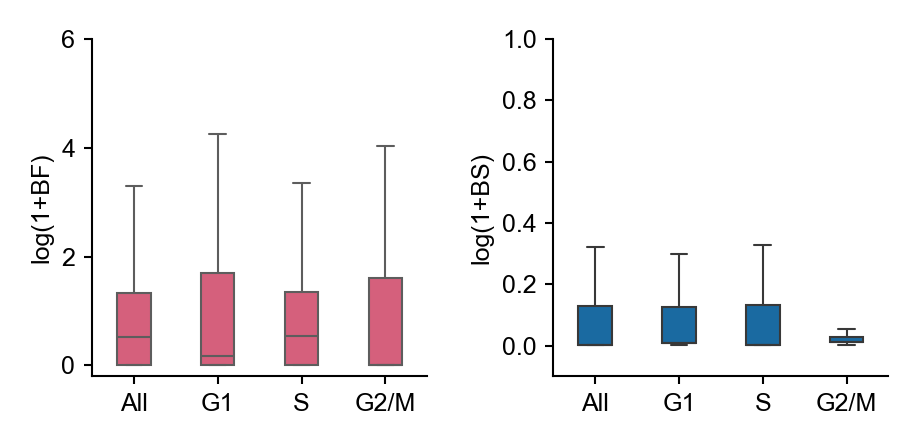

In [25]:
# import numpy as np
# import pandas as pd
# import matplotlib.pyplot as plt
# import seaborn as sns

PHASES = ["all", "G1", "S", "G2M"]
METRICS = ["bf", "bs"]
palette = ['#E94C72','#036EB8']
def make_long_df(df, metric, phases=PHASES):
    plot_df = pd.DataFrame({
        "phase": np.repeat(phases, len(df)),
        "value": np.concatenate([
            np.log1p(df[f"{metric}_{phase}"].values)
            for phase in phases
        ])
    })
    plot_df = plot_df.replace([np.inf, -np.inf], np.nan).dropna()
    return plot_df

fig, axes = plt.subplots(
    1, 2,
    figsize=(8 / 2.54, 4 / 2.54),
    sharey=False
)

for ax, metric in zip(axes, METRICS):
    plot_df = make_long_df(meta_data_merge, metric)
    color = palette[0] if metric == 'bf' else palette[1]
    sns.boxplot(
        data=plot_df,
        x="phase",
        y="value",
        order=PHASES,
        width=0.4,
        fliersize=0,
        linewidth=0.5,
        color=color,
        ax=ax,
    )

    if metric == 'bf':
        ax.set_ylim(-0.2, top=6)
    if metric == 'bs':
        ax.set_ylim(-0.1, top=1)

    ax.set_xlabel("")
    ax.set_ylabel(f"log(1+{metric.upper()})")
    xticklabels = ['All', 'G1', 'S', 'G2/M', ]
    ax.set_xticklabels(xticklabels, rotation=0)
    # ax.set_title(f"{metric}")

    # sns.despine(ax=ax)

# fig.suptitle("Burst kinetics stratified by cell-cycle phase\nusing DeepCycle labels", y=0.95)
plt.tight_layout()
plt.savefig(f"benchmarks/revised_v2/reviewer4/figures/cellcycle_burst_metrics_boxplot_{PARSE_ORIGIN}_{BURST_METHOD}.pdf", format='pdf', bbox_inches='tight')
plt.show()

### compute bs bf label consistencies

In [26]:
import numpy as np
import matplotlib.colors as mcolors


phases = ["all","G1", "S", "G2M"]
consistency_matrix = np.zeros((len(phases), len(phases), 4))  # 2 for bf and bs
for idx, indicator in enumerate(["bf", "bs",]):
    for i, phase1 in enumerate(phases):
        for j, phase2 in enumerate(phases):
            consistency = meta_data_merge[meta_data_merge[f"{indicator}_label_{phase1}"] == meta_data_merge[f"{indicator}_label_{phase2}"]].shape[0] / meta_data_merge.shape[0]
            consistency_matrix[i, j, idx] = consistency




### plot heatmap

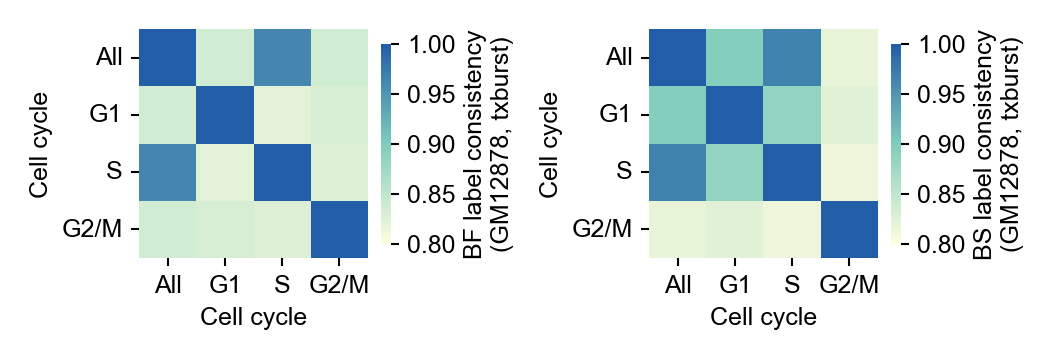

In [27]:
COLORS = ['#FFFDDF', "#7FCDBB", "#225EA8"]

fig, ax = plt.subplots(1,2, figsize=(9/2.54, 4/2.54))

for idx, indicator in enumerate(["bf", "bs",]):
    vmin = 0.8 if indicator == 'bf' else 0.8
    sns.heatmap(consistency_matrix[:,:,idx],cbar_kws={"shrink": 0.6, "fraction": 0.05},vmin=vmin, vmax=1,cmap=mcolors.LinearSegmentedColormap.from_list("colormap", COLORS, N=100), ax=ax[idx])

    ticklabels = ['All', 'G1', 'S', 'G2/M', ]
    ax[idx].set_xticklabels(ticklabels,rotation=0)
    ax[idx].set_yticklabels(ticklabels,rotation=0)
    ax[idx].set_aspect('equal')
    ax[idx].tick_params(axis='both',width=0.5)  # 修改刻度标签字体大小
    ax[idx].set_xlabel('Cell cycle', fontsize=6)
    ax[idx].set_ylabel('Cell cycle', fontsize=6)
    cbar = ax[idx].collections[0].colorbar
    # 调整colorbar的刻度粗细
    cbar.ax.tick_params(width=0.5,)  # 设置colorbar刻度的粗细
    cbar.set_label(f'{indicator.upper()} label consistency\n(GM12878, {BURST_METHOD})',fontsize=6)

# fig.suptitle("Consistency of burst label across cell cycles\nusing DeepCycle labels", y=0.95)
plt.tight_layout()
plt.savefig(f"benchmarks/revised_v2/reviewer4/figures/cellcycle_label_consistency_{PARSE_ORIGIN}_{BURST_METHOD}.pdf", format='pdf', bbox_inches='tight')
plt.show()